# Paddy Yield Prediction using KNN
## Data Loading

In [7]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [8]:
# Load dataset
df = pd.read_csv("../data/paddydataset.csv")

# Show dataset info
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2789, 45)


,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


## Feature Selection

In [9]:
# Define target variable (what we want to predict)
y = df["Paddy yield(in Kg)"]

# Define input features (all other columns)
X = df.drop(columns=["Paddy yield(in Kg)"])

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (2789, 44)
Target shape: (2789,)


## Train-Test Split

In [10]:
# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Data Preprocessing

In [12]:
# Separate categorical and numerical columns
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

# Create preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler()),
            ("var", VarianceThreshold(threshold=0.01))
        ]), num_cols),
        
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

## Model Training (KNN)

In [13]:
# Create KNN model pipeline
knn_model = Pipeline(steps=[
    ("prep", preprocess),
    ("regressor", KNeighborsRegressor(n_neighbors=5))
])

# Train model
knn_model.fit(X_train, y_train)

,steps,"[('prep', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Model Evaluation

In [14]:
# Make predictions
y_pred_knn = knn_model.predict(X_test)

# Evaluate performance
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print("KNN MAE:", mae_knn)
print("KNN RMSE:", rmse_knn)
print("KNN R2:", r2_knn)

KNN MAE: 629.8376344086022
KNN RMSE: 879.8437228048739
KNN R2: 0.9904558563618185


## Hyperparameter Tuning

In [15]:
k_values = [3, 5, 7, 9, 11]
r2_scores = []

for k in k_values:
    knn = Pipeline(steps=[
        ("prep", preprocess),
        ("regressor", KNeighborsRegressor(n_neighbors=k))
    ])
    
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    
    score = r2_score(y_test, pred)
    r2_scores.append(score)
    
    print(f"K={k}, R2 Score: {score}")

K=3, R2 Score: 0.9897325468381082
K=5, R2 Score: 0.9904558563618185
K=7, R2 Score: 0.9907360102701352
K=9, R2 Score: 0.9907069424621997
K=11, R2 Score: 0.9905713388321874


## Visualization

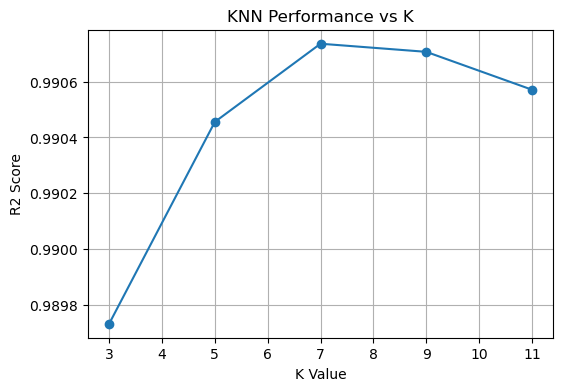

In [16]:
plt.figure(figsize=(6,4))
plt.plot(k_values, r2_scores, marker='o')
plt.xlabel("K Value")
plt.ylabel("R2 Score")
plt.title("KNN Performance vs K")
plt.grid(True)
plt.show()

In [21]:
best_k = k_values[r2_scores.index(max(r2_scores))]
print("Best K value:", best_k)

Best K value: 7


## Analysis

The performance of the KNN model was evaluated for different values of K. 
It was observed that the model achieved the highest R² score when K = 7.

Smaller values of K resulted in slightly lower performance due to overfitting, 
while larger values reduced accuracy due to excessive smoothing.

This demonstrates the importance of selecting an optimal K value for better model performance.